# Notebook 1 - Exploratory Data Analysis and Preprocessing

Afonso Fernandes

Lourenço Lima

Lucas Casimiro 20241796

In [7]:
import sys
import os

# Go up one level from notebooks/ to the project root
sys.path.insert(0, os.path.abspath('..'))

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler
import pickle
import warnings

from functions.eda import *
from functions.preprocessing import *
from functions.utils import *
%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Section 1: EDA on Raw Data


In [ ]:
customer_info = pd.read_csv('data/customer_info.csv')
customer_basket = pd.read_csv('data/customer_basket.csv')


In [11]:
print_overview(customer_info, customer_basket)

DATASET OVERVIEW

customer_info  : 33,038 rows  x  25 columns
customer_basket: 100,000 rows  x  3 columns

Unique customers in info  : 33,038
Unique customers in basket: 28,127

Total spend — mean : €23,615
Total spend — median : €20,180
Total spend — max  : €116,366


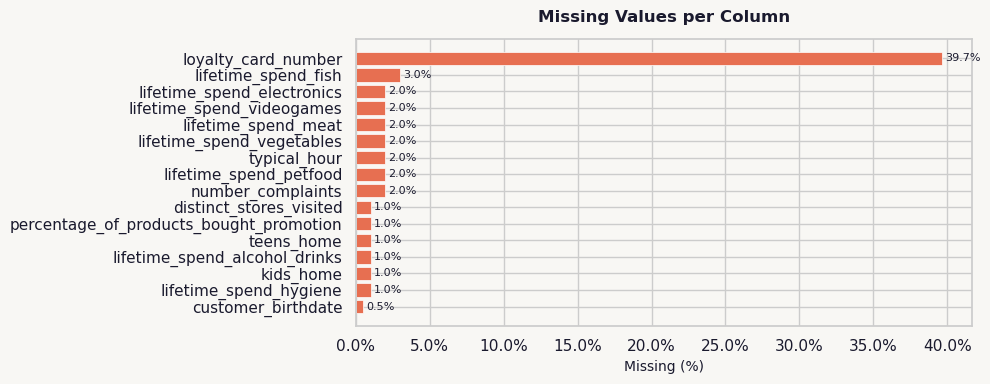

In [12]:
plot_missing_values(customer_info)

<string>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


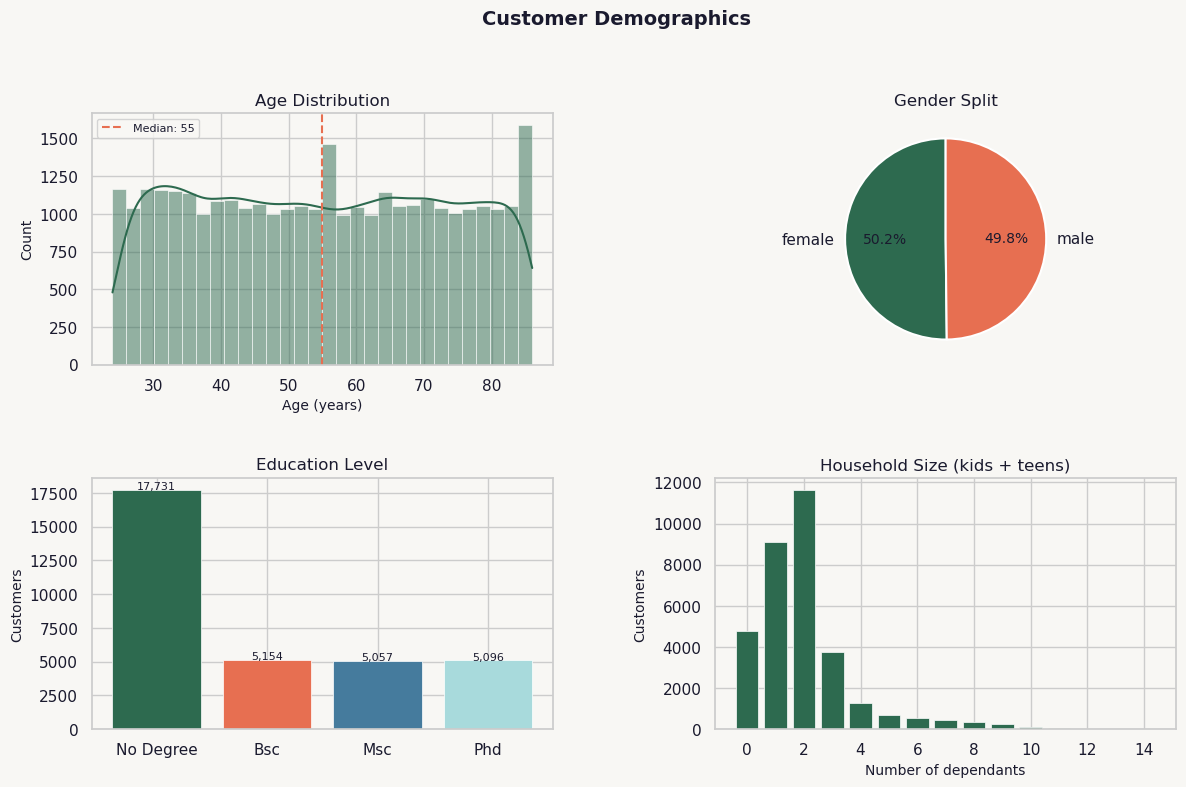

In [16]:
plot_demographics(customer_info)

<string>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


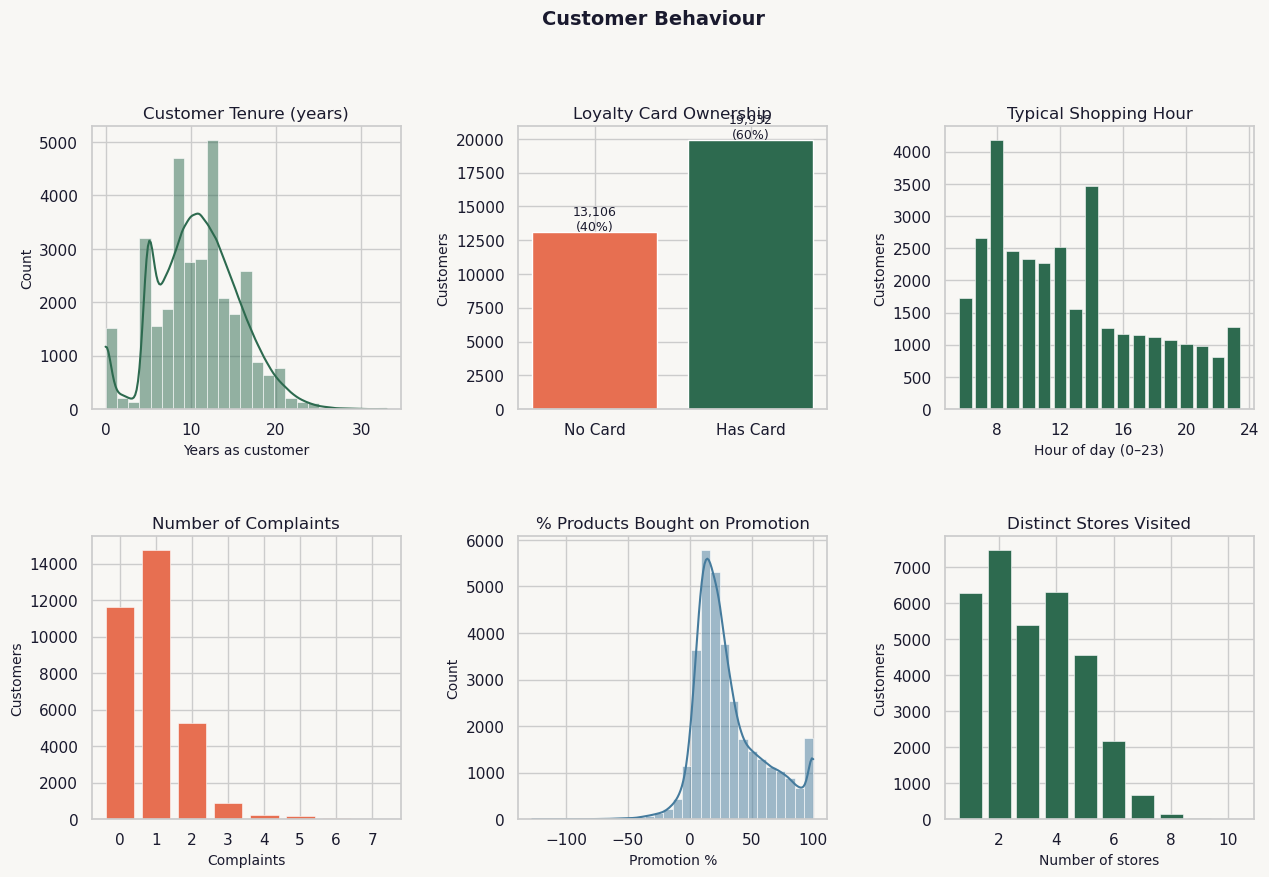

In [21]:
plot_customer_behavior(customer_info)

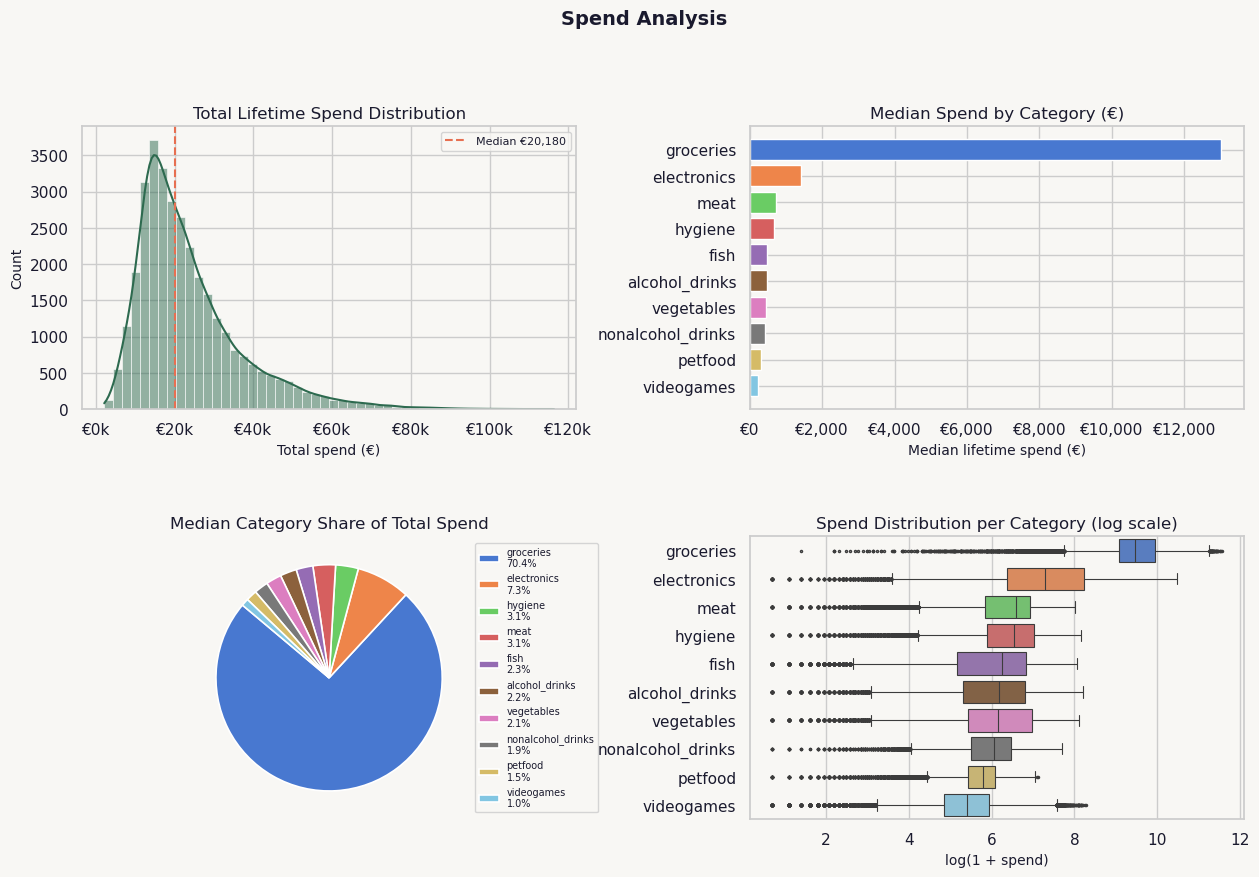

In [23]:
plot_spend_analysis(customer_info)

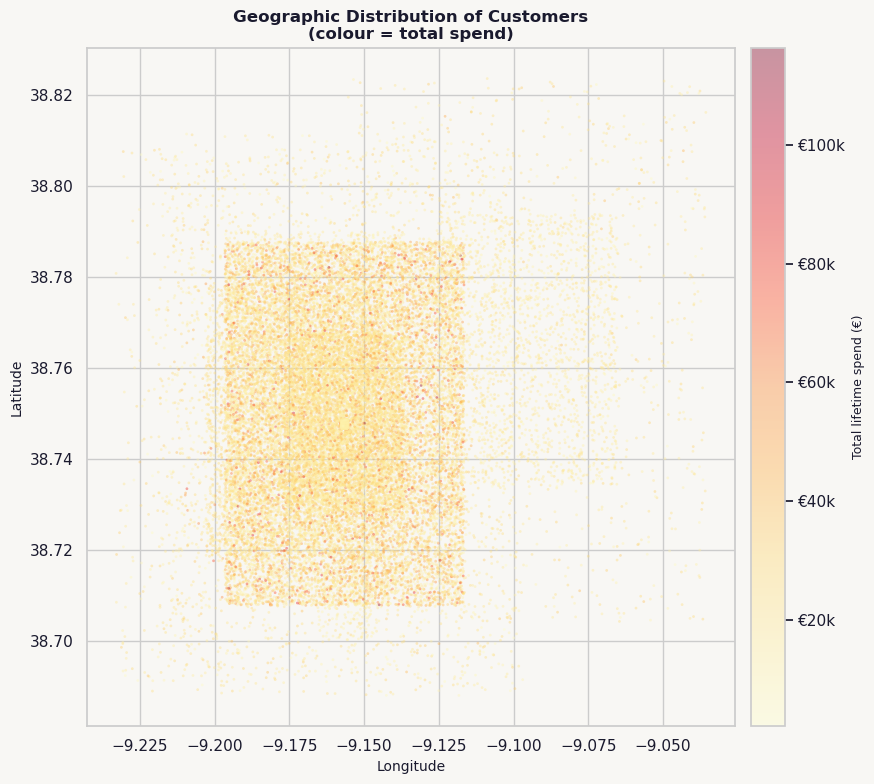

In [24]:
plot_geographic_distribution(customer_info)

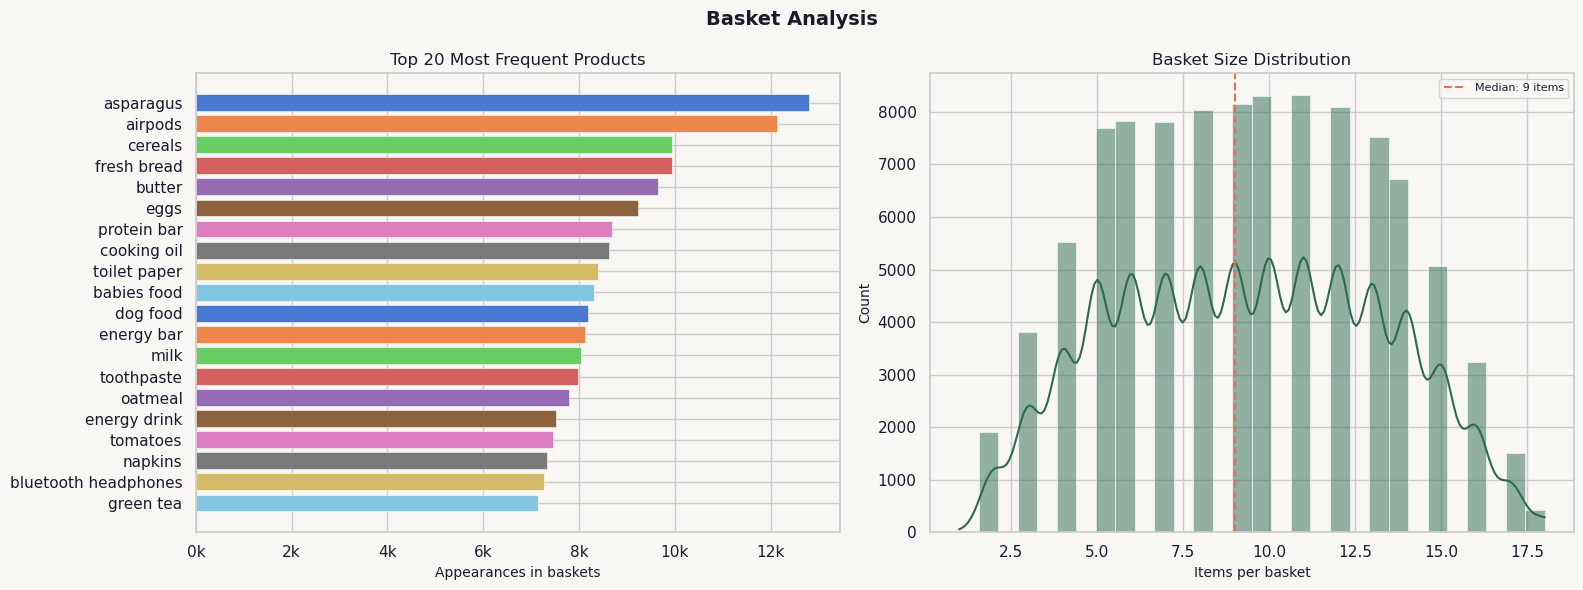

In [25]:
plot_basket_analysis(customer_basket, top_n=20)

# Section 2: Data Preprocessing and Feature Engineering

Apply preprocessing to raw data: handle missing values, create derived features (age, is_female, household_size, shares, etc.), and prepare for clustering.


In [28]:
# Apply preprocessing to create engineered features
customer_info_preprocessed = preprocessing(customer_info)
print("Preprocessing complete!")
print(f"Features created: {customer_info_preprocessed.shape[1]} columns")
display(customer_info_preprocessed.head())


Preprocessing complete!
Features created: 40 columns


,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
3,7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095


In [32]:
# Scale features for clustering
customer_scaled, scaler = scale_features(customer_info_preprocessed)
print("Scaling complete!")
display(customer_scaled[FEATURE_COLS].head())


Scaling complete!


,age,is_female,household_size,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0.03125,0.0,0.0,0.0,-0.714286,0.0,0.000,1.147251,0.461538,0.0,...,-0.350008,1.538609,-0.020252,-0.096317,-0.416981,-0.889505,-0.382116,-0.029743,0.311244,0.399106
1,-0.12500,0.0,-1.0,0.0,0.285714,-0.5,0.000,-0.262009,0.048951,-1.0,...,-0.130392,-0.228320,1.686147,0.440933,-0.574071,-0.870557,-0.744750,1.679631,0.530567,1.236579
2,0.00000,-1.0,-2.0,-1.0,1.428571,-0.5,-0.125,-0.498290,-0.293706,-1.0,...,0.450655,-0.654518,0.315733,-0.748057,-0.479881,1.554479,-0.175710,0.049021,-0.282499,-0.038382
3,-0.34375,-1.0,-2.0,0.0,-0.857143,-1.0,0.750,0.041426,-0.216783,1.0,...,-0.973212,0.007254,-0.330816,1.895790,1.739674,1.054119,1.681191,0.044439,8.226201,-0.173590
4,0.06250,-1.0,-2.0,0.0,-0.857143,-1.0,0.625,-0.154704,-0.818182,2.0,...,-1.668903,3.108581,-0.134922,0.237569,0.179075,0.331545,0.561586,-0.521282,3.167192,0.154859


# Section 3: Feature Analysis and Correlation

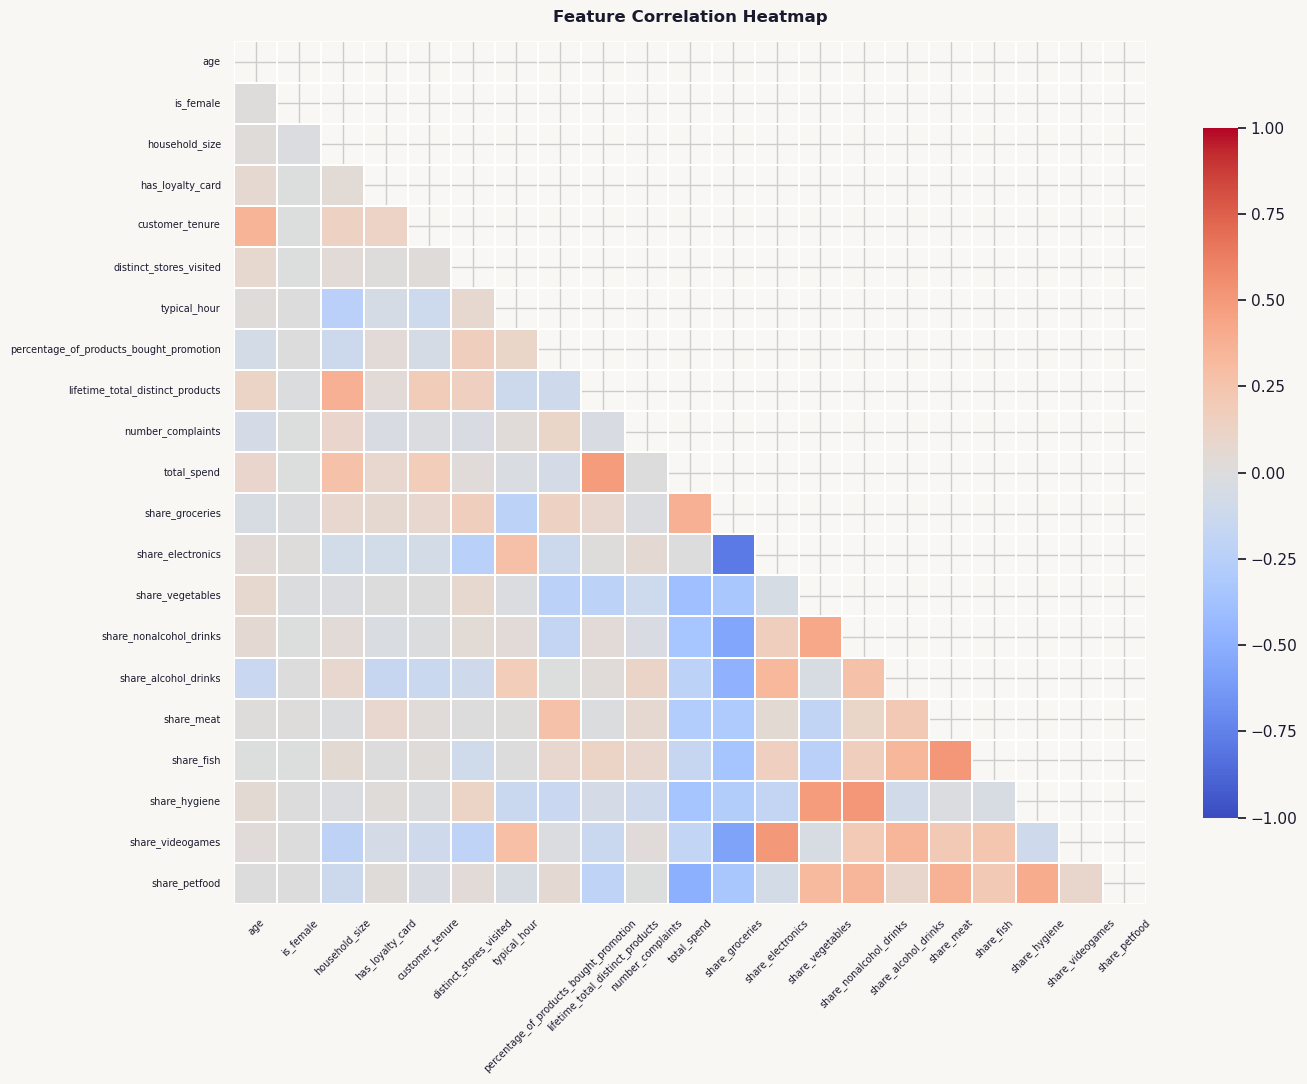

In [33]:
plot_correlation_heatmap(customer_scaled, feature_cols=FEATURE_COLS)
